In [1]:
!pip install pyspark boto3 -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.0 MB/s eta 0:00:00


In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("COVID_Excess_Deaths_Analytics") \
    .config("spark.jars.packages",
            "org.apache.hadoop:hadoop-aws:3.3.4,"
            "com.amazonaws:aws-java-sdk-bundle:1.12.262") \
    .master("local[*]") \
    .getOrCreate()

print("✔ Spark session created with AWS support!")


✔ Spark session created with AWS support!


In [ ]:
AWS_ACCESS_KEY = "YOUR_ACCESS_KEY"
AWS_SECRET_KEY = "YOUR_SECRET_KEY"
AWS_REGION     = "ap-south-1"
BUCKET_NAME    = "covid-excess-deaths-akne"

hadoopConf = spark._jsc.hadoopConfiguration()
hadoopConf.set("fs.s3a.access.key", AWS_ACCESS_KEY)
hadoopConf.set("fs.s3a.secret.key", AWS_SECRET_KEY)
hadoopConf.set("fs.s3a.endpoint", f"s3.{AWS_REGION}.amazonaws.com")
hadoopConf.set("fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")

print("✔ Spark is now configured for S3!")


✔ Spark is now configured for S3!


In [4]:
sex_age_path = f"s3a://{BUCKET_NAME}/raw/who_deaths_by_year_sex_age.csv"

sex_age_df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv(sex_age_path)

sex_age_df.printSchema()
sex_age_df.show(10)


Py4JJavaError: An error occurred while calling o34.csv.
: org.apache.hadoop.fs.s3a.AWSRedirectException: getFileStatus on s3a://covid-excess-deaths-akne/raw/who_deaths_by_year_sex_age.csv: com.amazonaws.services.s3.model.AmazonS3Exception: The bucket is in this region: ap-southeast-2. Please use this region to retry the request (Service: Amazon S3; Status Code: 301; Error Code: 301 Moved Permanently; Request ID: QA5T8K5JTPXPZC2B; S3 Extended Request ID: mANs5n3tGKRoPQTNf+ot7JNgL0ibohUJIpVp5iU2FIMMszC/m+vhWZiJ/GAIg2wNgSgTDNJsjtM=; Proxy: null), S3 Extended Request ID: mANs5n3tGKRoPQTNf+ot7JNgL0ibohUJIpVp5iU2FIMMszC/m+vhWZiJ/GAIg2wNgSgTDNJsjtM=:301 Moved Permanently: The bucket is in this region: ap-southeast-2. Please use this region to retry the request (Service: Amazon S3; Status Code: 301; Error Code: 301 Moved Permanently; Request ID: QA5T8K5JTPXPZC2B; S3 Extended Request ID: mANs5n3tGKRoPQTNf+ot7JNgL0ibohUJIpVp5iU2FIMMszC/m+vhWZiJ/GAIg2wNgSgTDNJsjtM=; Proxy: null)
	at org.apache.ha

In [5]:
!pip install pyspark boto3 -q

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("COVID_Excess_Deaths_Analytics") \
    .config("spark.jars.packages",
            "org.apache.hadoop:hadoop-aws:3.3.4,"
            "com.amazonaws:aws-java-sdk-bundle:1.12.262") \
    .master("local[*]") \
    .getOrCreate()

print("✔ Spark session created with AWS support!")


✔ Spark session created with AWS support!


In [ ]:
AWS_ACCESS_KEY = "YOUR_ACCESS_KEY"
AWS_SECRET_KEY = "YOUR_SECRET_KEY"
AWS_REGION     = "ap-southeast-2"       # <-- FIXED REGION
BUCKET_NAME    = "covid-excess-deaths-akne"

# Configure Spark to use S3
hadoopConf = spark._jsc.hadoopConfiguration()
hadoopConf.set("fs.s3a.access.key", AWS_ACCESS_KEY)
hadoopConf.set("fs.s3a.secret.key", AWS_SECRET_KEY)
hadoopConf.set("fs.s3a.endpoint", f"s3.{AWS_REGION}.amazonaws.com")  # <-- FIXED ENDPOINT
hadoopConf.set("fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")

print("✔ Spark is now configured for S3!")


✔ Spark is now configured for S3!


In [7]:
sex_age_path = f"s3a://{BUCKET_NAME}/raw/who_deaths_by_year_sex_age.csv"

sex_age_df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv(sex_age_path)

sex_age_df.printSchema()
sex_age_df.show(10)


Py4JJavaError: An error occurred while calling o44.csv.
: org.apache.hadoop.fs.s3a.AWSRedirectException: getFileStatus on s3a://covid-excess-deaths-akne/raw/who_deaths_by_year_sex_age.csv: com.amazonaws.services.s3.model.AmazonS3Exception: The bucket is in this region: ap-southeast-2. Please use this region to retry the request (Service: Amazon S3; Status Code: 301; Error Code: 301 Moved Permanently; Request ID: 85E6F5284GGX7DJC; S3 Extended Request ID: 02AzpCbhkKfwESBNWWlnwe3xmTncA6GeUbgPqYsti7MofYhafTK1sHToBHDiHvnlRQjHsDN+H03OL/wslyyJ5MwRMumyKK0r; Proxy: null), S3 Extended Request ID: 02AzpCbhkKfwESBNWWlnwe3xmTncA6GeUbgPqYsti7MofYhafTK1sHToBHDiHvnlRQjHsDN+H03OL/wslyyJ5MwRMumyKK0r:301 Moved Permanently: The bucket is in this region: ap-southeast-2. Please use this region to retry the request (Service: Amazon S3; Status Code: 301; Error Code: 301 Moved Permanently; Request ID: 85E6F5284GGX7DJC; S3 Extended Request ID: 02AzpCbhkKfwESBNWWlnwe3xmTncA6GeUbgPqYsti7MofYhafTK1sHToBHDiHvnlRQjH

In [ ]:
import boto3
import pandas as pd

AWS_ACCESS_KEY = "YOUR_ACCESS_KEY"
AWS_SECRET_KEY = "YOUR_SECRET_KEY"
BUCKET_NAME    = "covid-excess-deaths-akne"
FILE_KEY       = "raw/who_deaths_by_year_sex_age.csv"

s3 = boto3.client(
    "s3",
    aws_access_key_id=AWS_ACCESS_KEY,
    aws_secret_access_key=AWS_SECRET_KEY
)

obj = s3.get_object(Bucket=BUCKET_NAME, Key=FILE_KEY)

pdf = pd.read_csv(obj['Body'])
pdf.head()


,country,Country name,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,iso3,ISO 3166-1 alpha-3 code,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,year,Year of death,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,sex,Sex (Female or Male),NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,age_group,Age-group from 0 to 85 plus,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,type,Estimate type for select year (reported or pre...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
sex_age_df = spark.createDataFrame(pdf)
sex_age_df.printSchema()
sex_age_df.show(5)


root
 |-- country: string (nullable = true)
 |-- Country name: string (nullable = true)
 |-- Unnamed: 2: string (nullable = true)
 |-- Unnamed: 3: string (nullable = true)
 |-- Unnamed: 4: string (nullable = true)
 |-- Unnamed: 5: string (nullable = true)
 |-- Unnamed: 6: string (nullable = true)
 |-- Unnamed: 7: string (nullable = true)
 |-- Unnamed: 8: string (nullable = true)

+---------+--------------------+----------+----------+----------+----------+----------+----------+----------+
|  country|        Country name|Unnamed: 2|Unnamed: 3|Unnamed: 4|Unnamed: 5|Unnamed: 6|Unnamed: 7|Unnamed: 8|
+---------+--------------------+----------+----------+----------+----------+----------+----------+----------+
|     iso3|ISO 3166-1 alpha-...|       NaN|       NaN|       NaN|       NaN|       NaN|       NaN|       NaN|
|     year|       Year of death|       NaN|       NaN|       NaN|       NaN|       NaN|       NaN|       NaN|
|      sex|Sex (Female or Male)|       NaN|       NaN|       NaN|  

In [10]:
obj = s3.get_object(Bucket="covid-excess-deaths-akne", Key="raw/who_deaths_by_year_sex_age.csv")
pdf = pd.read_csv(obj['Body'], skiprows=7)  # FIXED
print(pdf.head())


       acm.mean Estimated deaths from all-causes by age, sex and year (mean)  \
0  excess.mean*  Excess deaths associated with COVID-19 pandemi...             
1           NaN                                                NaN             
2       country                                               iso3             
3   Afghanistan                                                AFG             
4   Afghanistan                                                AFG             

  Unnamed: 2 Unnamed: 3 Unnamed: 4 Unnamed: 5        Unnamed: 6  \
0        NaN        NaN        NaN        NaN               NaN   
1        NaN        NaN        NaN        NaN               NaN   
2       year        sex  age_group       type     expected.mean   
3       2020     Female       0-24  predicted  49083.6439335266   
4       2020     Female      25-34  predicted   6452.9670394984   

         Unnamed: 7        Unnamed: 8  
0               NaN               NaN  
1               NaN               Na

In [11]:
pdf.columns = [
    "country",
    "iso3",
    "year",
    "sex",
    "age_group",
    "type",
    "expected_mean",
    "acm_mean",
    "excess_mean"
]
pdf.head()


,country,iso3,year,sex,age_group,type,expected_mean,acm_mean,excess_mean
0,excess.mean*,Excess deaths associated with COVID-19 pandemi...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,country,iso3,year,sex,age_group,type,expected.mean,acm.mean,excess.mean*
3,Afghanistan,AFG,2020,Female,0-24,predicted,49083.6439335266,49103.1431533225,0
4,Afghanistan,AFG,2020,Female,25-34,predicted,6452.9670394984,6691.24721854869,236.607817172177


In [12]:
sex_age_df = spark.createDataFrame(pdf)
sex_age_df.printSchema()
sex_age_df.show(5)


root
 |-- country: string (nullable = true)
 |-- iso3: string (nullable = true)
 |-- year: string (nullable = true)
 |-- sex: string (nullable = true)
 |-- age_group: string (nullable = true)
 |-- type: string (nullable = true)
 |-- expected_mean: string (nullable = true)
 |-- acm_mean: string (nullable = true)
 |-- excess_mean: string (nullable = true)

+------------+--------------------+----+------+---------+---------+----------------+----------------+----------------+
|     country|                iso3|year|   sex|age_group|     type|   expected_mean|        acm_mean|     excess_mean|
+------------+--------------------+----+------+---------+---------+----------------+----------------+----------------+
|excess.mean*|Excess deaths ass...| NaN|   NaN|      NaN|      NaN|             NaN|             NaN|             NaN|
|         NaN|                 NaN| NaN|   NaN|      NaN|      NaN|             NaN|             NaN|             NaN|
|     country|                iso3|year|   sex|a

In [13]:
# Remove rows where year = 'year' or country contains description text
clean_df = sex_age_df.filter(sex_age_df.year != "year")

# Also remove any completely blank rows
clean_df = clean_df.dropna(subset=["country", "year", "sex"])

clean_df.show(10)
clean_df.printSchema()


+------------+--------------------+----+------+---------+---------+----------------+----------------+----------------+
|     country|                iso3|year|   sex|age_group|     type|   expected_mean|        acm_mean|     excess_mean|
+------------+--------------------+----+------+---------+---------+----------------+----------------+----------------+
|excess.mean*|Excess deaths ass...| NaN|   NaN|      NaN|      NaN|             NaN|             NaN|             NaN|
|         NaN|                 NaN| NaN|   NaN|      NaN|      NaN|             NaN|             NaN|             NaN|
| Afghanistan|                 AFG|2020|Female|     0-24|predicted|49083.6439335266|49103.1431533225|               0|
| Afghanistan|                 AFG|2020|Female|    25-34|predicted| 6452.9670394984|6691.24721854869|236.607817172177|
| Afghanistan|                 AFG|2020|Female|    35-44|predicted|6117.87310635972|  6977.363938828| 860.30071392836|
| Afghanistan|                 AFG|2020|Female| 

In [14]:
from pyspark.sql.functions import col

# Keep rows where year is numeric only
clean_df = clean_df.filter(col("year").rlike("^[0-9]{4}$"))

clean_df.show(10)
clean_df.printSchema()


+-----------+----+----+------+---------+---------+----------------+----------------+----------------+
|    country|iso3|year|   sex|age_group|     type|   expected_mean|        acm_mean|     excess_mean|
+-----------+----+----+------+---------+---------+----------------+----------------+----------------+
|Afghanistan| AFG|2020|Female|     0-24|predicted|49083.6439335266|49103.1431533225|               0|
|Afghanistan| AFG|2020|Female|    25-34|predicted| 6452.9670394984|6691.24721854869|236.607817172177|
|Afghanistan| AFG|2020|Female|    35-44|predicted|6117.87310635972|  6977.363938828| 860.30071392836|
|Afghanistan| AFG|2020|Female|    45-54|predicted|7711.68953142234|9330.21731710218|1621.57180617288|
|Afghanistan| AFG|2020|Female|    55-64|predicted|10061.5441565976|12457.9850857855|2401.48897102767|
|Afghanistan| AFG|2020|Female|    65-74|predicted|13955.3421144752| 17144.299885298|3195.44937263931|
|Afghanistan| AFG|2020|Female|    75-84|predicted|12751.7113222847|14639.041244292

In [15]:
from pyspark.sql.types import DoubleType
from pyspark.sql.functions import col

numeric_df = clean_df.withColumn("expected_mean", col("expected_mean").cast(DoubleType())) \
                     .withColumn("acm_mean", col("acm_mean").cast(DoubleType())) \
                     .withColumn("excess_mean", col("excess_mean").cast(DoubleType()))

numeric_df.printSchema()
numeric_df.show(5)


root
 |-- country: string (nullable = true)
 |-- iso3: string (nullable = true)
 |-- year: string (nullable = true)
 |-- sex: string (nullable = true)
 |-- age_group: string (nullable = true)
 |-- type: string (nullable = true)
 |-- expected_mean: double (nullable = true)
 |-- acm_mean: double (nullable = true)
 |-- excess_mean: double (nullable = true)

+-----------+----+----+------+---------+---------+----------------+----------------+----------------+
|    country|iso3|year|   sex|age_group|     type|   expected_mean|        acm_mean|     excess_mean|
+-----------+----+----+------+---------+---------+----------------+----------------+----------------+
|Afghanistan| AFG|2020|Female|     0-24|predicted|49083.6439335266|49103.1431533225|             0.0|
|Afghanistan| AFG|2020|Female|    25-34|predicted| 6452.9670394984|6691.24721854869|236.607817172177|
|Afghanistan| AFG|2020|Female|    35-44|predicted|6117.87310635972|  6977.363938828| 860.30071392836|
|Afghanistan| AFG|2020|Female| 

In [16]:
from pyspark.sql.functions import sum as _sum, avg as _avg, round as _round, col

country_kpi_df = numeric_df.groupBy("country").agg(
    _sum("excess_mean").alias("total_excess_deaths"),
    _avg("excess_mean").alias("avg_excess_deaths")
)

country_kpi_df = country_kpi_df.withColumn("total_excess_deaths", _round(col("total_excess_deaths"), 2))
country_kpi_df = country_kpi_df.withColumn("avg_excess_deaths", _round(col("avg_excess_deaths"), 2))

country_kpi_df.show(10)


+--------------------+-------------------+-----------------+
|             country|total_excess_deaths|avg_excess_deaths|
+--------------------+-------------------+-----------------+
|Micronesia (Feder...|               75.0|             2.34|
|          Cabo Verde|             634.19|            19.82|
|            Kiribati|              161.3|             5.04|
|   Republic of Korea|            9628.71|            300.9|
|              Guyana|            3821.23|           119.41|
|             Eritrea|            2040.74|            63.77|
|            Djibouti|            1158.41|             36.2|
|                Fiji|            1722.87|            53.84|
|                Iraq|           44847.05|          1401.47|
|             Germany|          101504.97|          3172.03|
+--------------------+-------------------+-----------------+
only showing top 10 rows



In [17]:
country_sex_kpi_df = numeric_df.groupBy("country", "sex").agg(
    _sum("excess_mean").alias("total_excess_deaths")
)

country_sex_kpi_df = country_sex_kpi_df.withColumn(
    "total_excess_deaths", _round(col("total_excess_deaths"), 2)
)

country_sex_kpi_df.show(10)


+--------------------+------+-------------------+
|             country|   sex|total_excess_deaths|
+--------------------+------+-------------------+
|               Gabon|Female|             457.33|
|            Honduras|  Male|           11632.36|
|               Japan|  Male|           58340.85|
|              Jordan|Female|            6583.18|
| Antigua and Barbuda|Female|             -34.57|
|      CÃ´te d'Ivoire|Female|            6847.86|
|Iran (Islamic Rep...|  Male|          157227.06|
|            Honduras|Female|            8273.77|
|Bolivia (Plurinat...|  Male|           56728.34|
|             Germany|Female|           46698.62|
+--------------------+------+-------------------+
only showing top 10 rows



In [18]:
country_age_kpi_df = numeric_df.groupBy("country", "age_group").agg(
    _sum("excess_mean").alias("total_excess_deaths")
)

country_age_kpi_df = country_age_kpi_df.withColumn(
    "total_excess_deaths", _round(col("total_excess_deaths"), 2)
)

country_age_kpi_df.show(10)


+--------------------+---------+-------------------+
|             country|age_group|total_excess_deaths|
+--------------------+---------+-------------------+
|Democratic Republ...|    45-54|           10827.78|
|         Afghanistan|    35-44|            7215.64|
|             Georgia|    35-44|             155.61|
|              Jordan|    75-84|            3490.25|
|          Kazakhstan|    75-84|           22594.22|
|             Eritrea|     0-24|                0.0|
|           Indonesia|    65-74|          301550.87|
|             Andorra|    25-34|              -0.04|
|             Bahamas|    55-64|             286.73|
|Democratic Republ...|    55-64|           13686.35|
+--------------------+---------+-------------------+
only showing top 10 rows



In [19]:
import pandas as pd

# Convert to Pandas
country_kpi_pdf = country_kpi_df.toPandas()
country_sex_pdf = country_sex_kpi_df.toPandas()
country_age_pdf = country_age_kpi_df.toPandas()

# Save locally
country_kpi_pdf.to_csv("country_kpi.csv", index=False)
country_sex_pdf.to_csv("country_sex_kpi.csv", index=False)
country_age_pdf.to_csv("country_age_kpi.csv", index=False)

# Upload to S3
s3.upload_file("country_kpi.csv", BUCKET_NAME, "processed/country_kpi.csv")
s3.upload_file("country_sex_kpi.csv", BUCKET_NAME, "processed/country_sex_kpi.csv")
s3.upload_file("country_age_kpi.csv", BUCKET_NAME, "processed/country_age_kpi.csv")

print("Processed KPI files uploaded to S3!")


Processed KPI files uploaded to S3!


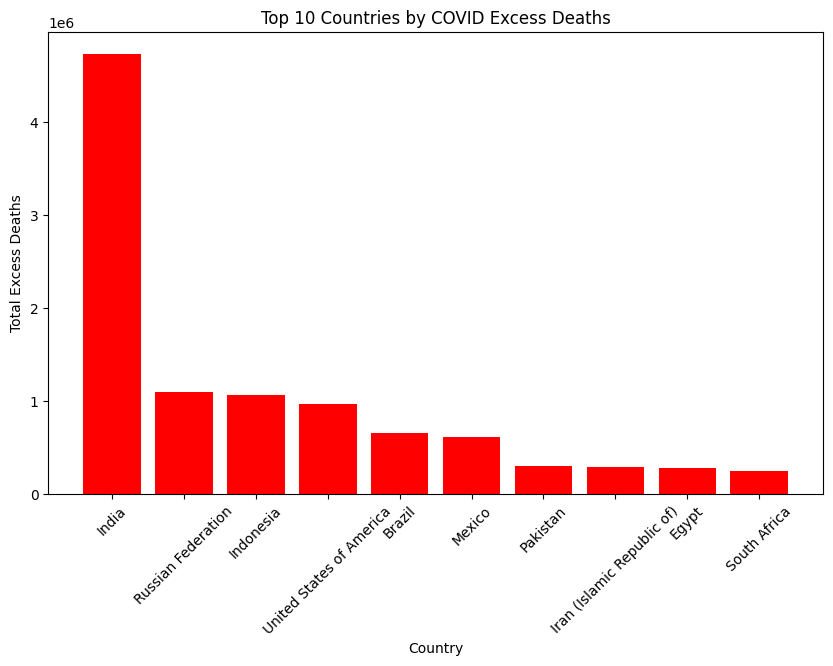

In [20]:
import matplotlib.pyplot as plt

top10 = country_kpi_pdf.sort_values(by="total_excess_deaths", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10["country"], top10["total_excess_deaths"], color='red')
plt.xticks(rotation=45)
plt.title("Top 10 Countries by COVID Excess Deaths")
plt.xlabel("Country")
plt.ylabel("Total Excess Deaths")
plt.show()


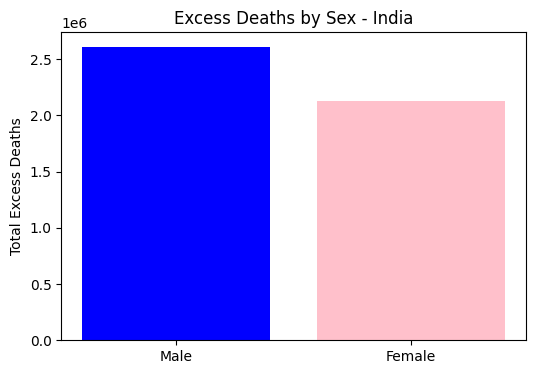

In [21]:
india = country_sex_pdf[country_sex_pdf["country"] == "India"]

plt.figure(figsize=(6,4))
plt.bar(india["sex"], india["total_excess_deaths"], color=['blue','pink'])
plt.title("Excess Deaths by Sex - India")
plt.ylabel("Total Excess Deaths")
plt.show()


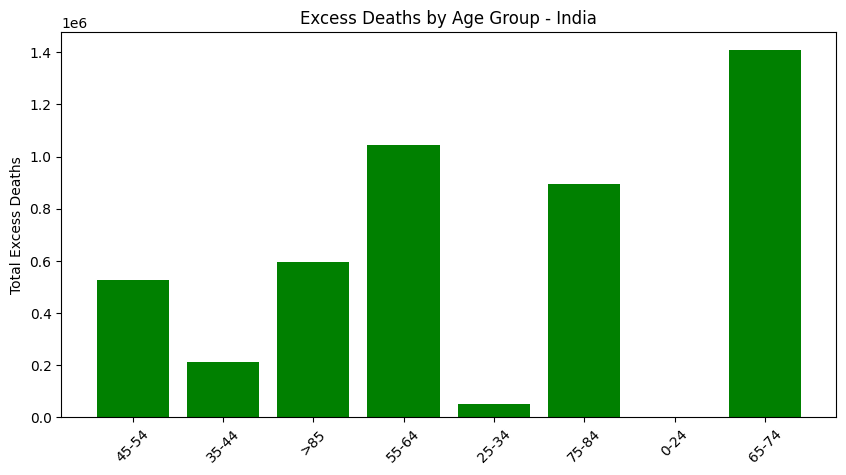

In [22]:
india_age = country_age_pdf[country_age_pdf["country"] == "India"]

plt.figure(figsize=(10,5))
plt.bar(india_age["age_group"], india_age["total_excess_deaths"], color='green')
plt.xticks(rotation=45)
plt.title("Excess Deaths by Age Group - India")
plt.ylabel("Total Excess Deaths")
plt.show()


In [1]:
from google.colab import files
files.download("country_kpi.csv")
files.download("country_sex_kpi.csv")
files.download("country_age_kpi.csv")


FileNotFoundError: Cannot find file: country_kpi.csv

In [2]:
who_df.columns, country_kpi_df.columns, country_sex_kpi_df.columns


NameError: name 'who_df' is not defined

In [3]:
!pip install pyspark boto3 openpyxl -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 106.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.6 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import time

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum as _sum, avg as _avg, count as _count, round as _round


In [5]:
spark = SparkSession.builder.appName("COVID_Excess_Deaths").master("local[*]").getOrCreate()


In [ ]:
AWS_ACCESS_KEY = "YOUR_ACCESS_KEY"
AWS_SECRET_KEY = "YOUR_SECRET_KEY"
AWS_REGION = "ap-southeast-2"
BUCKET_NAME = "covid-excess-deaths-akne"

spark._jsc.hadoopConfiguration().set("fs.s3a.access.key", AWS_ACCESS_KEY)
spark._jsc.hadoopConfiguration().set("fs.s3a.secret.key", AWS_SECRET_KEY)
spark._jsc.hadoopConfiguration().set("fs.s3a.endpoint", f"s3.{AWS_REGION}.amazonaws.com")
spark._jsc.hadoopConfiguration().set("fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")




In [7]:
from google.colab import files
uploaded = files.upload()


Saving WHO_COVID_Excess_Deaths_EstimatesByCountry.xlsx to WHO_COVID_Excess_Deaths_EstimatesByCountry.xlsx


In [8]:
processed/country_kpi.csv


NameError: name 'processed' is not defined